<a href="https://colab.research.google.com/github/astgregory/Task_21-PredictionsOfRussianWriters/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D1%8F%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9621.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Когда вы еще учились в школе, то вас часто мучали написанием сочинений. Может быть даже кто-нибудь из вас увлекался написанием стихотворений, романов или прозы. А значит, в вас живет дух великого русского писателя. А вот интересно какого? В данной домашней работе мы это и выясним!

Чтобы узнать на какого писателя вы похожи необходимо выполнить следующее задание:

1. Скачать датасет с [писателями Русской литературы](https://storage.yandexcloud.net/academy.ai/russian_literature.zip). Каждый текст необходимо разбить на обучающую, проверочную и тестовую выборки, для этого модифицируйте функцию `seq_vectorize`, чтобы она возвращала все 3 выборки.
2. Используя материалы из ноутбука практического занятия [сравнение архитектур рекуррентных и одномерных сверточных сетей](https://colab.research.google.com/drive/15-SEqMwU3ALZmiEtlJFZllc38VTGHkGu), выберите лучший вариант нейронки и адаптируйте ее структуру.
3. Подгрузите веса Наташи как в уроке [20.3](https://colab.research.google.com/drive/1g_dX1XpRY--X6EjFflCC0717p9_9Y1SP) для слоя эмбендинга.
4. Заморозьте слой эмбединга.
5. Обучите модель на любом числе писателей (не менее 4-х) с балансировкой. Используйте обучающую выборку для обучения, а проверочную - в качестве валидационных данных (`validation_data`).
6. Постройте матрицу ошибок на тестовых образцах! В примерах мы строили на проверочных. Добейтесь средней точности более 70% на тестовых образцах. Получите 3 балла.
7. Если сможете добиться точности более 90% получите +1 балл.
8. Подготовьте свой текст и предложите нейронке предсказать на кого из русских писателей похож ваш текст. Вам необходимо построить круговую диаграмму с вероятностями предсказания моделью автора сочинения (по тестовой выборке). Если текст будет вашего авторства, то вы получите +1 балл. Если у вас плохо с фантазией, то возьмите небольшой фрагмент вашего любимого произведения любого автора, не представленного в датасете.

# **Решение с писателями Русской литературы**

In [ ]:
from keras.models import Sequential, load_model
from keras.utils import get_file, to_categorical
from keras.layers import Embedding, Flatten, Dense, SpatialDropout1D, BatchNormalization, Dropout, SimpleRNN
from keras.layers import GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D
from keras.callbacks import ModelCheckpoint

from tensorflow.keras.preprocessing.text import Tokenizer

import os   # Модуль для работы с файловой системой
import zipfile

import glob # Вспомогательный модуль для работы с файловой системой
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Для работы с матрицей ошибок

import matplotlib.pyplot as plt
%matplotlib inline

**Загрузка и распаковка датасета**

In [ ]:
data_path = get_file(
    "russian_literature.zip",
    "https://storage.yandexcloud.net/academy.ai/russian_literature.zip",
    cache_dir='.')

def unzip_with_encoding(zip_file_path, extract_to_dir, encoding='utf-8'):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        for member in zip_ref.namelist():
            decoded_member = member.encode('cp437').decode(encoding)

            if len(decoded_member) > 255:
                decoded_member = decoded_member[:255]

            extracted_member_path = os.path.join(extract_to_dir, decoded_member)

            os.makedirs(os.path.dirname(extracted_member_path), exist_ok=True)

            with open(extracted_member_path, 'wb') as outfile:
                with zip_ref.open(member) as file:
                    outfile.write(file.read())

extract_to_directory = './dataset'
unzip_with_encoding(data_path, extract_to_directory, encoding='utf-8')

21547079/21547079 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


**Загрузка предлбученных весов Наташа**

In [ ]:
!wget https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar

!pip install navec

from navec import Navec

navec = Navec.load('navec_hudlit_v1_12B_500K_300d_100q.tar')

--2025-11-13 09:43:54--  https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53012480 (51M) [application/x-tar]
Saving to: ‘navec_hudlit_v1_12B_500K_300d_100q.tar’

navec_hudlit_v1_12B 100%[===================>]  50.56M  9.56MB/s    in 7.1s    

2025-11-13 09:44:02 (7.16 MB/s) - ‘navec_hudlit_v1_12B_500K_300d_100q.tar’ saved [53012480/53012480]



**Формирование датасета**

In [ ]:
FILE_DIR_POEMS = './dataset/poems'
file_list_poems = os.listdir(FILE_DIR_POEMS)

FILE_DIR_PROSE = './dataset/prose'
file_list_prose = os.listdir(FILE_DIR_PROSE)

CLASS_LIST = list(set(file_list_poems + file_list_prose))

all_texts = {} # Собираем в словарь весь датасет

for author in CLASS_LIST:
    all_texts[author] = '' # Инициализируем пустой строкой новый ключ словаря
    for path in glob.glob('./dataset/prose/{}/*.txt'.format(author)) +  glob.glob('./dataset/poems/{}/*.txt'.format(author)): # Поиск файлов по шаблону
        with open(f'{path}', 'r', errors='ignore') as f: # игнорируем ошибки (например символы из другой кодировки)
            # Загрузка содержимого файла в строку
            text = f.read()

        all_texts[author]  += ' ' + text.replace('\n', ' ') # Заменяем символ перехода на новую строку пробелом

**Токенизация**

In [ ]:
embedding_dim = 300    # размерность векторов эмбединга (300d в имени эмбединга)
max_words = 15000      # Количество слов, рассматриваемых как признаки

# Используется встроенный в Keras токенизатор для разбиения текста и построения частотного словаря
tokenizer = Tokenizer(num_words=max_words,
                      filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                      lower=True, split=' ', char_level=False)


# Построение частотного словаря по текстам
tokenizer.fit_on_texts(all_texts.values())

In [ ]:
seq_train = tokenizer.texts_to_sequences(all_texts.values())

**Балансировка датасета**

In [ ]:
# используем генератор цикла для получения длины текстов по каждому автору
total = sum(len(i) for i in seq_train)
print(f'Датасет состоит из {total} слов')

print('Общая выборка по писателям (по словам):')
mean_list = np.array([])
for author in CLASS_LIST:
    cls = CLASS_LIST.index(author)
    print(f'{author} - {len(seq_train[cls])} слов, доля в общей базе: {len(seq_train[cls])/total*100 :.2f}%')
    mean_list = np.append(mean_list, len(seq_train[cls]))

print('Среднее значение слов: ', np.round(mean_list.mean()))
print('Медианное значение слов: ', np.median(mean_list))


median = int(np.median(mean_list)) # Зафиксировали медианное значение
CLASS_LIST_BALANCE = [] # Сбалансированный набор меток
seq_train_balance = []
for author in CLASS_LIST:
    cls = CLASS_LIST.index(author)
    if len(seq_train[cls]) > median * 1.2 :
      seq_train_balance.append(seq_train[cls][:median])
      CLASS_LIST_BALANCE.append(author)

Датасет состоит из 5021084 слов
Общая выборка по писателям (по словам):
Bryusov - 349393 слов, доля в общей базе: 6.96%
Herzen - 153382 слов, доля в общей базе: 3.05%
Tolstoy - 1236843 слов, доля в общей базе: 24.63%
Gogol - 288952 слов, доля в общей базе: 5.75%
Gorky - 553889 слов, доля в общей базе: 11.03%
Blok - 85449 слов, доля в общей базе: 1.70%
Nekrasov - 39266 слов, доля в общей базе: 0.78%
Turgenev - 305421 слов, доля в общей базе: 6.08%
Chekhov - 244755 слов, доля в общей базе: 4.87%
Dostoevsky - 1548451 слов, доля в общей базе: 30.84%
Pushkin - 168349 слов, доля в общей базе: 3.35%
Lermontov - 46934 слов, доля в общей базе: 0.93%
Среднее значение слов:  418424.0
Медианное значение слов:  266853.5


In [ ]:
total = sum(len(i) for i in seq_train_balance)

print('Сбалансированная выборка по писателям (по словам):')
mean_list_balance = np.array([])
for author in CLASS_LIST_BALANCE:
    cls = CLASS_LIST_BALANCE.index(author)
    print(f'{author} - {len(seq_train_balance[cls])} слов, доля в общей базе: {len(seq_train_balance[cls])/total*100 :.2f}%')
    mean_list_balance = np.append(mean_list_balance, len(seq_train_balance[cls]))

print('Среднее значение слов: ', np.round(mean_list_balance.mean()))
print('Медианное значение слов: ', np.median(mean_list_balance))

Сбалансированная выборка по писателям (по словам):
Bryusov - 266853 слов, доля в общей базе: 25.00%
Tolstoy - 266853 слов, доля в общей базе: 25.00%
Gorky - 266853 слов, доля в общей базе: 25.00%
Dostoevsky - 266853 слов, доля в общей базе: 25.00%
Среднее значение слов:  266853.0
Медианное значение слов:  266853.0


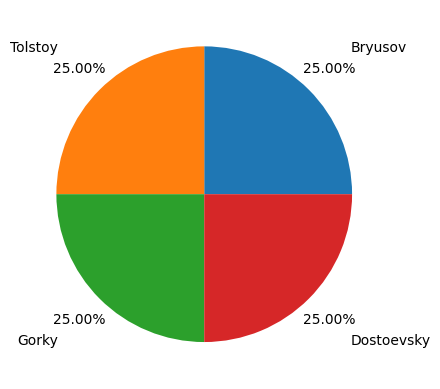

In [ ]:
fig, ax = plt.subplots()
ax.pie([len(i) for i in seq_train_balance],  # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST_BALANCE,            # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

In [ ]:
# используем генератор цикла для получения длины текстов по каждому автору
total = sum(len(i) for i in seq_train_balance)
print(f'Датасет состоит из {total} слов')

Датасет состоит из 1067412 слов


In [ ]:
print('Общая выборка по писателям (по словам):')
mean_list = np.array([])
for author in CLASS_LIST_BALANCE:
    cls = CLASS_LIST_BALANCE.index(author)
    print(f'{author} - {len(seq_train_balance[cls])} слов, доля в общей базе: {len(seq_train_balance[cls])/total*100 :.2f}%')
    mean_list = np.append(mean_list, len(seq_train_balance[cls]))

print('Среднее значение слов: ', np.round(mean_list.mean()))
print('Медианное значение слов: ', np.median(mean_list))

Общая выборка по писателям (по словам):
Bryusov - 266853 слов, доля в общей базе: 25.00%
Tolstoy - 266853 слов, доля в общей базе: 25.00%
Gorky - 266853 слов, доля в общей базе: 25.00%
Dostoevsky - 266853 слов, доля в общей базе: 25.00%
Среднее значение слов:  266853.0
Медианное значение слов:  266853.0


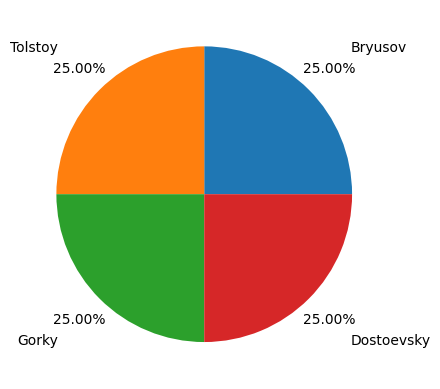

In [ ]:
fig, ax = plt.subplots()
ax.pie([len(i) for i in seq_train_balance], # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST_BALANCE,                    # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

**Формирование выборок**

In [ ]:
WIN_SIZE = 1000   # Ширина окна в токенах
WIN_STEP = 100    # Шаг окна в токенах

# Функция разбиения последовательности на отрезки скользящим окном
# Последовательность разбивается на части до последнего полного окна
# Параметры:
# sequence - последовательность токенов
# win_size - размер окна
# step - шаг окна
def seq_split(sequence, win_size, step):
    # Делим строку на отрезки с помощью генератора цикла
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, step)]

def seq_vectorize(
    seq_list,    # Последовательность
    test_split,  # Доля на тестовую выборку
    val_split,   # Доля на валидационную выборку
    class_list,  # Список классов
    win_size,    # Ширина скользящего окна
    step         # Шаг скользящего окна
):

    # Списки для результирующих данных
    x_train, y_train, x_val, y_val, x_test, y_test = [], [], [], [], [], []

    # Пробежимся по всем классам:
    for class_item in class_list:
        # Получим индекс класса
        cls = class_list.index(class_item)

        # Получаем длину последовательности текущего класса
        total_length = len(seq_list[cls])

        # Пороговое значение индексов для разбивки на тренинг, валидацию и тест:
        test_start_index = int(total_length * (1 - test_split))
        val_start_index = int(total_length * (1 - test_split - val_split))

        # Разбиваем последовательность токенов класса на отрезки
        vectors_train = seq_split(seq_list[cls][:val_start_index], win_size, step)      # обучение
        vectors_val = seq_split(seq_list[cls][val_start_index:test_start_index], win_size, step)  # валидация
        vectors_test = seq_split(seq_list[cls][test_start_index:], win_size, step)      # тест

        # Добавляем отрезки в выборку
        x_train += vectors_train
        x_val += vectors_val
        x_test += vectors_test

        # Для всех отрезков класса добавляем метки класса в виде one-hot-encoding
        y_train += [to_categorical(cls, len(class_list))] * len(vectors_train)
        y_val += [to_categorical(cls, len(class_list))] * len(vectors_val)
        y_test += [to_categorical(cls, len(class_list))] * len(vectors_test)

    # Возвращаем результаты как numpy-массивов
    return (np.array(x_train), np.array(y_train), np.array(x_val), np.array(y_val), np.array(x_test), np.array(y_test))

In [ ]:
test_split = 0.1
val_split = 0.1

x_train, y_train, x_val, y_val, x_test, y_test = seq_vectorize(
    seq_train_balance,
    test_split,
    val_split,
    CLASS_LIST_BALANCE,
    WIN_SIZE,
    WIN_STEP
)

In [ ]:
print(f'Форма входных данных для обучающей выборки: {x_train.shape}')
print(f'Форма выходных данных (меток) для обучающей выборки: {y_train.shape}')

Форма входных данных для обучающей выборки: (8500, 1000)
Форма выходных данных (меток) для обучающей выборки: (8500, 4)


In [ ]:
print(f'Форма входных данных для тестовой выборки: {x_val.shape}')
print(f'Форма выходных данных (меток) для тестовой выборки: {y_val.shape}')

Форма входных данных для тестовой выборки: (1028, 1000)
Форма выходных данных (меток) для тестовой выборки: (1028, 4)


In [ ]:
print(f'Форма входных данных для тестовой выборки: {x_test.shape}')
print(f'Форма выходных данных (меток) для тестовой выборки: {y_test.shape}')

Форма входных данных для тестовой выборки: (1028, 1000)
Форма выходных данных (меток) для тестовой выборки: (1028, 4)


**Определение вспомогательных функций**

In [ ]:
# Вывод графиков точности и ошибки
def show_plot(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('График процесса обучения модели: '+title)
    ax1.plot(history.history['accuracy'],
               label='График точности на обучающей выборке')
    ax1.plot(history.history['val_accuracy'],
               label='График точности на проверочной выборке')
    ax1.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('График точности')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающей выборке')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочной выборке')
    ax2.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()

# Функция вывода предсказанных значений
def show_confusion_matrix(y_true, y_pred, class_labels):
    # Матрица ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, 3)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(f'Матрица ошибок', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Убираем ненужную цветовую шкалу
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси
    plt.show()


    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))

In [ ]:
def loadEmbedding():
    word_index = tokenizer.word_index
    embeddings_index = navec

    embedding_matrix = np.zeros((max_words, embedding_dim))
    for word, i in word_index.items():
        if i < max_words:
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector

    return embedding_matrix

**Создание архитектуры сети и обучение модели**

In [ ]:
model_MIX = Sequential()
model_MIX.add(Embedding(max_words, embedding_dim, input_length=WIN_SIZE, weights=loadEmbedding()))
model_MIX.add(SpatialDropout1D(0.3))
model_MIX.add(BatchNormalization())

# Два двунаправленных рекуррентных слоя LSTM
model_MIX.add(Bidirectional(LSTM(8, return_sequences=True)))
model_MIX.add(Bidirectional(LSTM(8, return_sequences=True)))
model_MIX.add(Dropout(0.3))
model_MIX.add(BatchNormalization())

# Два рекуррентных слоя GRU
model_MIX.add(GRU(16, return_sequences=True, reset_after=True))
model_MIX.add(GRU(16, reset_after=True))
model_MIX.add(Dropout(0.3))
model_MIX.add(BatchNormalization())

# Дополнительный полносвязный слой
model_MIX.add(Dense(100, activation='relu'))
model_MIX.add(Dropout(0.3))
model_MIX.add(BatchNormalization())
model_MIX.add(Dense(len(CLASS_LIST_BALANCE), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model_MIX.layers[0].trainable = False

In [ ]:
checkpoint_callback = ModelCheckpoint(
    'best_model_mix.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

In [ ]:
model_MIX.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_mix = model_MIX.fit(x_train, y_train, epochs=50, batch_size=128, validation_data=(x_val, y_val), callbacks=[checkpoint_callback])

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.2613 - loss: 1.8037
Epoch 1: val_accuracy improved from -inf to 0.31420, saving model to best_model_mix.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - accuracy: 0.2614 - loss: 1.8024 - val_accuracy: 0.3142 - val_loss: 1.3818
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.3042 - loss: 1.5435
Epoch 2: val_accuracy improved from 0.31420 to 0.37743, saving model to best_model_mix.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 182ms/step - accuracy: 0.3043 - loss: 1.5430 - val_accuracy: 0.3774 - val_loss: 1.3416
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.3438 - loss: 1.4187
Epoch 3: val_accuracy improved from 0.37743 to 0.39494, saving model to best_model_mix.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.3440 - loss: 1.4182 - val_accuracy: 0.3949 - val_loss: 1.2644
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.4045 - loss: 1.2912
Epoch 4: val_accuracy improved from 0.39494 to 0.43288, saving model to best_model_mix.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - accuracy: 0.4047 - loss: 1.2909 - val_accuracy: 0.4329 - val_loss: 1.1864
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.4534 - loss: 1.2076
Epoch 5: val_accuracy improved from 0.43288 to 0.50486, saving model to best_model_mix.h5


...

67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.7878 - loss: 0.6248 - val_accuracy: 0.7821 - val_loss: 0.6504
Epoch 13/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8088 - loss: 0.5689
Epoch 13: val_accuracy improved from 0.78210 to 0.80739, saving model to best_model_mix.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.8089 - loss: 0.5686 - val_accuracy: 0.8074 - val_loss: 0.5767
Epoch 14/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.7857 - loss: 0.6013
Epoch 14: val_accuracy did not improve from 0.80739
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.7851 - loss: 0.6027 - val_accuracy: 0.6800 - val_loss: 0.7890
Epoch 15/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8013 - loss: 0.5885
Epoch 15: val_accuracy did not improve from 0.80739
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.8014 - loss: 0.5883 - val_accuracy: 0.7646 - val_loss: 0.6393
Epoch 16/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.7847 - loss: 0.6296
Epoch 16: val_accuracy did not improve from 0.80739
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.7845 - loss: 0.6300 - val_accuracy: 0.5982 - val_loss: 1.0650
Epoch 17/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.7886 - loss: 0.5929
Epoch 17: val_accuracy d

67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.9288 - loss: 0.2432 - val_accuracy: 0.8833 - val_loss: 0.4200
Epoch 23/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9338 - loss: 0.2155
Epoch 23: val_accuracy did not improve from 0.88327
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.9339 - loss: 0.2154 - val_accuracy: 0.8687 - val_loss: 0.3848
Epoch 24/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9355 - loss: 0.2108
Epoch 24: val_accuracy improved from 0.88327 to 0.94844, saving model to best_model_mix.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.9356 - loss: 0.2106 - val_accuracy: 0.9484 - val_loss: 0.1614
Epoch 25/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9541 - loss: 0.1644
Epoch 25: val_accuracy did not improve from 0.94844
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.9540 - loss: 0.1645 - val_accuracy: 0.9154 - val_loss: 0.2846
Epoch 26/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9544 - loss: 0.1742
Epoch 26: val_accuracy did not improve from 0.94844
67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.9544 - loss: 0.1743 - val_accuracy: 0.8833 - val_loss: 0.3709
Epoch 27/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9556 - loss: 0.1548
Epoch 27: val_accuracy did not improve from 0.94844
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.9556 - loss: 0.1547 - val_accuracy: 0.8531 - val_loss: 0.5553
Epoch 28/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9688 - loss: 0.1246
Epoch 28: val_accuracy d

67/67 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - accuracy: 0.9917 - loss: 0.0320 - val_accuracy: 0.9708 - val_loss: 0.1101
Epoch 46/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9921 - loss: 0.0296
Epoch 46: val_accuracy did not improve from 0.97082
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.9921 - loss: 0.0296 - val_accuracy: 0.9173 - val_loss: 0.2878
Epoch 47/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9938 - loss: 0.0231
Epoch 47: val_accuracy did not improve from 0.97082
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.9938 - loss: 0.0231 - val_accuracy: 0.8911 - val_loss: 0.4880
Epoch 48/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9943 - loss: 0.0238
Epoch 48: val_accuracy did not improve from 0.97082
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.9943 - loss: 0.0238 - val_accuracy: 0.9329 - val_loss: 0.2604
Epoch 49/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9910 - loss: 0.0386
Epoch 49: val_accuracy d

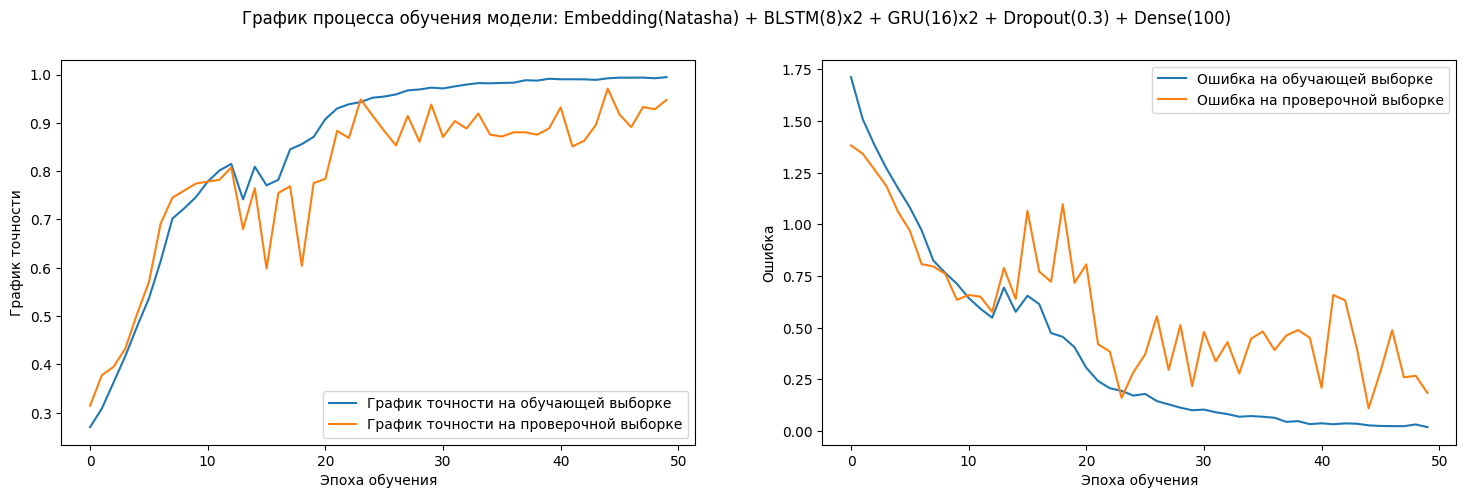

In [ ]:
show_plot(history_mix, 'Embedding(Natasha) + BLSTM(8)x2 + GRU(16)x2 + Dropout(0.3) + Dense(100)')

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step


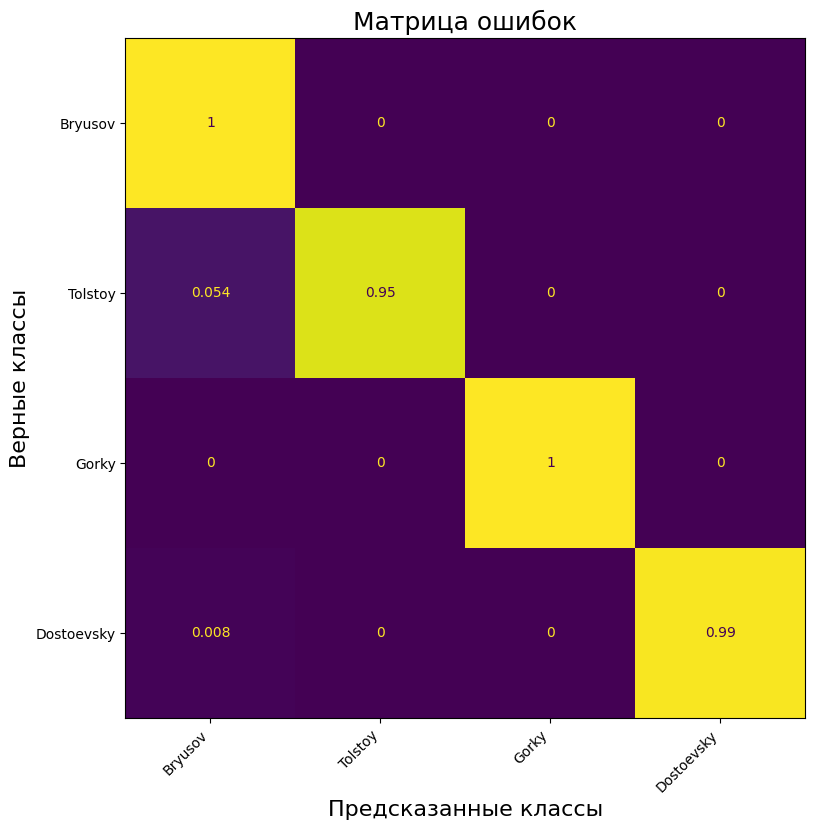


Средняя точность распознавания:  98%


In [ ]:
model = load_model('best_model_mix.h5')
y_pred_mix = model.predict(x_test)
show_confusion_matrix(y_test, y_pred_mix, CLASS_LIST_BALANCE)

# **Предсказание своего текста**

In [ ]:
text = """
Среди шумного гомона городской жизни, неизменного пейзажа непрошенных забот
и меланхолии повседневности, я встречаюсь со своей мечтой. Мечта – это невероятный
мир, где небо становится ярким, а сердца наполняются светом. Наполняясь словами,
моя душа распускается, словно цветы весной, открывая двери к бескрайним возможностям.
"""

In [ ]:
from keras.preprocessing.sequence import pad_sequences

def preprocess_text(text):

    tokens = tokenizer.texts_to_sequences([text])
    padded_tokens = pad_sequences(tokens, maxlen=WIN_SIZE)
    return padded_tokens

padded_text = preprocess_text(text)

predictions = model.predict(padded_text)
predicted_authors_probabilities = predictions[0]

author_labels = CLASS_LIST_BALANCE
author_probabilities = predicted_authors_probabilities

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


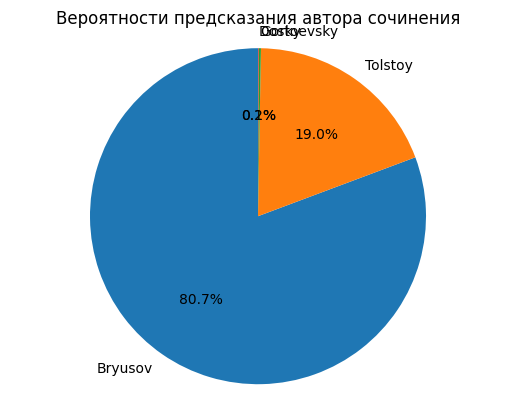

In [ ]:
fig, ax = plt.subplots()
ax.pie(author_probabilities,
       labels=author_labels,
       autopct='%1.1f%%',
       startangle=90)
ax.axis('equal')

plt.title('Вероятности предсказания автора сочинения')
plt.show()